# Logistic Regression for Binary Classification

### The Logistic Regression Model
  - ##### Sigmoid Function
    - Maps the output to a range between 0 and 1
    - If prediction is >= 0.5 then prediction is class 1, otherwise it is classs 0
    - It ensures outputs are interpretable as probabilities
    - Visualization of the sigmoid function can illustrate how probabilities are mapped from raw model predictions
   
   - ##### Decision Boundary
     - The threshold (default is 0.5) used to classify instances
     - Adjusting the threshold can balance precision and recall depending on the use case
     - Decision boundaries can be adjusted to optimize for precision or recall

   - ##### Interpretation of Coefficients
     - B0 : Intercept, the baseline probability
     - B1: Effect of feature xi on the log-odds of the positive class

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [11]:
# Generating some values
z = np.linspace(-10,10,100)
sigmoid_values = sigmoid(z)
c = np.hstack((z,sigmoid_values))
print(c)

[-1.00000000e+01 -9.79797980e+00 -9.59595960e+00 -9.39393939e+00
 -9.19191919e+00 -8.98989899e+00 -8.78787879e+00 -8.58585859e+00
 -8.38383838e+00 -8.18181818e+00 -7.97979798e+00 -7.77777778e+00
 -7.57575758e+00 -7.37373737e+00 -7.17171717e+00 -6.96969697e+00
 -6.76767677e+00 -6.56565657e+00 -6.36363636e+00 -6.16161616e+00
 -5.95959596e+00 -5.75757576e+00 -5.55555556e+00 -5.35353535e+00
 -5.15151515e+00 -4.94949495e+00 -4.74747475e+00 -4.54545455e+00
 -4.34343434e+00 -4.14141414e+00 -3.93939394e+00 -3.73737374e+00
 -3.53535354e+00 -3.33333333e+00 -3.13131313e+00 -2.92929293e+00
 -2.72727273e+00 -2.52525253e+00 -2.32323232e+00 -2.12121212e+00
 -1.91919192e+00 -1.71717172e+00 -1.51515152e+00 -1.31313131e+00
 -1.11111111e+00 -9.09090909e-01 -7.07070707e-01 -5.05050505e-01
 -3.03030303e-01 -1.01010101e-01  1.01010101e-01  3.03030303e-01
  5.05050505e-01  7.07070707e-01  9.09090909e-01  1.11111111e+00
  1.31313131e+00  1.51515152e+00  1.71717172e+00  1.91919192e+00
  2.12121212e+00  2.32323

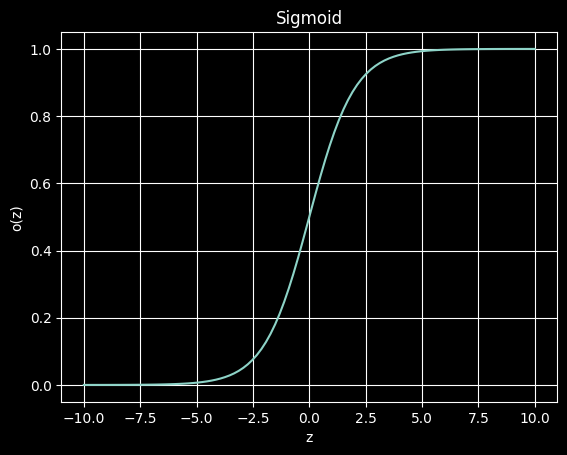

In [12]:
plt.plot(z, sigmoid_values)
plt.title("Sigmoid")
plt.xlabel("z")
plt.ylabel("o(z)")
plt.grid()
plt.show()

---

# Implementing a logistic regression model 
To classify a dataset (e.g, predicting if a customer will make a purchase)

In [15]:
# importing more lib
import pandas as pd
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

Explanation:

- `X[:,0]`: Selects the first feature (column) from all rows of X.
- `X[:,1]`: Selects the second feature (column) from all rows of X.
- `X[:,0]*1.5 + X[:,1]`: Multiplies the first feature by 1.5 and adds the second feature, for each sample.
- `> 15`: Checks if the result is greater than 15. This creates a boolean array (True or False for each sample).
- `.astype(int)`: Converts True to 1 and False to 0

In [16]:
# generating the synthetic data
np.random.seed(42)
n_samples = 200
X = np.random.rand(n_samples,2)*10
y = (X[:,0]*1.5+X[:,1]>15).astype(int) #check above

In [19]:
# Converting to dataframe or creating the dataframe
df = pd.DataFrame(X, columns=['Age','Salary'])
df['Purchase'] = y

In [22]:
print(df.head())

        Age    Salary  Purchase
0  3.745401  9.507143         1
1  7.319939  5.986585         1
2  1.560186  1.559945         0
3  0.580836  8.661761         0
4  6.011150  7.080726         1


In [20]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(df[['Age','Salary']], df['Purchase'], test_size=0.2, random_state = 42)

In [21]:
# Train Logistic regression
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
# Make Prediction
y_pred = model.predict(X_test)

In [25]:
#Evaluate Performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("Cause we are using synthetic data everything is perfect")

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Cause we are using synthetic data everything is perfect


In [32]:
# Ploting the result

# Ploting the decision boundary

# this will give us the min x and max x
x_min, x_max = X[:,0].min() - 1   ,  X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1,  X[:,1].max() + 1

# this will will give us mesg grid based on the values
xx, yy = np.meshgrid(np.arange(x_min, x_max,0.1), np.arange(y_min, y_max,0.1))

In [34]:
# Predict Probabilites for grid points
Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


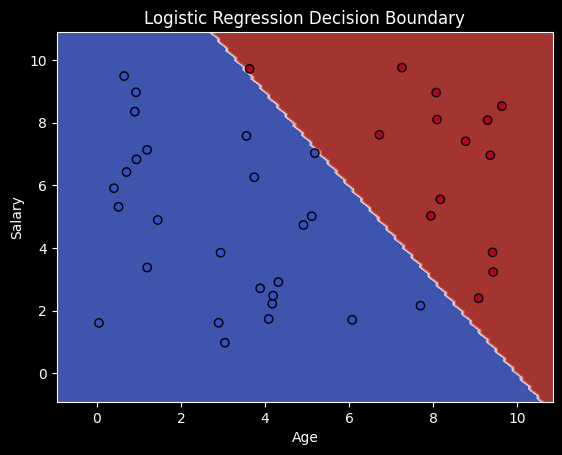

In [47]:
# Plot
plt.contourf(xx, yy,Z,alpha=0.8, cmap = "coolwarm")
plt.scatter(X_test['Age'], X_test['Salary'],c=y_test,edgecolor="k",cmap="coolwarm")
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()